In [7]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

In [8]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_test_s = scaler.transform(X_test).astype(np.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)
X_train_t = torch.tensor(X_train_s)
X_test_t = torch.tensor(X_test_s)

In [9]:

# --- Simple MLP ---
class SimpleMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze()

In [ ]:
# --- Constraint: "Patients with BOTH large worst radius AND high concave points 
#     should have LOW probability of being benign" ---

def constraint_loss(model, X_batch, feature_names, lambda_constraint=1.0):
    """
    Penalize the model when it predicts high P(benign) for patients
    whose 'worst radius' and 'worst concave points' are both above
    the 75th percentile.
    """
    worst_radius_idx = list(feature_names).index('worst radius')
    worst_concave_idx = list(feature_names).index('worst concave points')
    
    # These thresholds are on the standardized scale
    # (roughly: 75th percentile of training data ≈ +0.67 in standard normal)
    radius_high = X_batch[:, worst_radius_idx] > 0.67
    concave_high = X_batch[:, worst_concave_idx] > 0.67
    both_high = radius_high & concave_high
    
    if both_high.sum() == 0:
        return torch.tensor(0.0)
    
    # For these patients, the model should predict LOW P(benign)
    # Penalize predictions that are above 0.3 for this group
    preds = model(X_batch[both_high])
    penalty = torch.relu(preds - 0.3).mean()
    return lambda_constraint * penalty

In [11]:
# --- Training loop with and without constraint ---
def train_model(use_constraint=False, lambda_val=1.0, epochs=150):
    model = SimpleMLP(X_train_s.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    bce = nn.BCELoss()
    
    losses = {'bce': [], 'constraint': [], 'total': []}
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        preds = model(X_train_t)
        loss_bce = bce(preds, y_train_t)
        
        if use_constraint:
            loss_c = constraint_loss(model, X_train_t, data.feature_names, lambda_val)
        else:
            loss_c = torch.tensor(0.0)
        
        total_loss = loss_bce + loss_c
        total_loss.backward()
        optimizer.step()
        
        losses['bce'].append(loss_bce.item())
        losses['constraint'].append(loss_c.item())
        losses['total'].append(total_loss.item())
    
    return model, losses

In [ ]:
# Train both versions
model_unconstrained, losses_u = train_model(use_constraint=False)
model_constrained, losses_c = train_model(use_constraint=True, lambda_val=2.0)

# Evaluate
for name, model in [("Unconstrained", model_unconstrained), ("Constrained", model_constrained)]:
    model.eval()
    with torch.no_grad():
        preds = (model(X_test_t) > 0.5).int().numpy()
    print(f"\n=== {name} ===")
    print(classification_report(y_test, preds, target_names=data.target_names))

# --- Analyze: Focus specifically on patients in the "both high" region
model_unconstrained.eval()
model_constrained.eval()
with torch.no_grad():
    preds_u = model_unconstrained(X_test_t).numpy()
    preds_c = model_constrained(X_test_t).numpy()

worst_radius_idx = list(data.feature_names).index('worst radius')
worst_concave_idx = list(data.feature_names).index('worst concave points')
high_risk = (X_test_s[:, worst_radius_idx] > 0.67) & (X_test_s[:, worst_concave_idx] > 0.67)

print(f"\nPatients in 'both high' region: {high_risk.sum()}")
print(f"Unconstrained avg P(benign) for this group: {preds_u[high_risk].mean():.3f}")
print(f"Constrained avg P(benign) for this group: {preds_c[high_risk].mean():.3f}")
print(f"Actual benign rate for this group: {y_test[high_risk].mean():.3f}")



=== Unconstrained ===
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        43
      benign       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


=== Constrained ===
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        43
      benign       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Patients in 'both high' region: 24
Unconstrained avg P(benign) for this group: 0.000
Constrained avg P(benign) for this group: 0.002
Actual benign rate for this group: 0.000


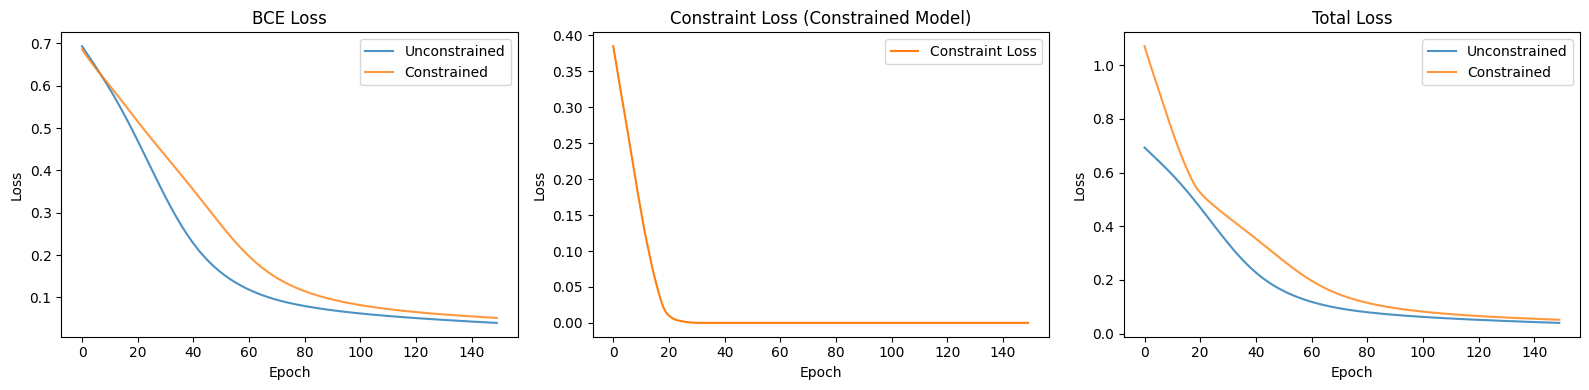

In [14]:
import matplotlib.pyplot as plt
 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
 
# BCE Loss comparison
axes[0].plot(losses_u['bce'], label='Unconstrained', alpha=0.8)
axes[0].plot(losses_c['bce'], label='Constrained', alpha=0.8)
axes[0].set_title('BCE Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
 
# Constraint loss (only meaningful for the constrained model)
axes[1].plot(losses_c['constraint'], label='Constraint Loss', color='tab:orange')
axes[1].set_title('Constraint Loss (Constrained Model)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
 
# Total loss comparison
axes[2].plot(losses_u['total'], label='Unconstrained', alpha=0.8)
axes[2].plot(losses_c['total'], label='Constrained', alpha=0.8)
axes[2].set_title('Total Loss')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].legend()
 
plt.tight_layout()
plt.show()
 

λ=0.0  |  Accuracy: 0.9737  |  Avg P(benign) high-risk group: 0.0016
λ=0.5  |  Accuracy: 0.9737  |  Avg P(benign) high-risk group: 0.0006
λ=1.0  |  Accuracy: 0.9825  |  Avg P(benign) high-risk group: 0.0040
λ=2.0  |  Accuracy: 0.9825  |  Avg P(benign) high-risk group: 0.0015
λ=5.0  |  Accuracy: 0.9912  |  Avg P(benign) high-risk group: 0.0060


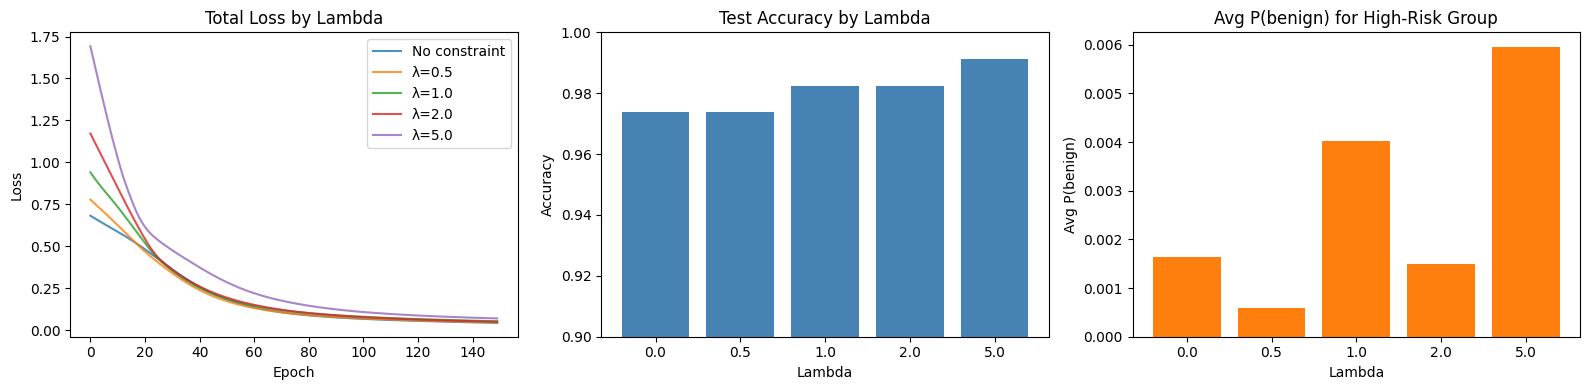

In [15]:
import matplotlib.pyplot as plt

lambda_values = [0.0, 0.5, 1.0, 2.0, 5.0]
results = {}

for lam in lambda_values:
    use_c = lam > 0
    model, losses = train_model(use_constraint=use_c, lambda_val=lam, epochs=150)
    model.eval()
    with torch.no_grad():
        preds = model(X_test_t).numpy()
        acc = ((preds > 0.5).astype(int) == y_test).mean()
        avg_benign_high_risk = preds[high_risk].mean()
    results[lam] = {
        'model': model,
        'losses': losses,
        'accuracy': acc,
        'avg_p_benign_high_risk': avg_benign_high_risk,
        'total_losses': losses['total']
    }
    print(f"λ={lam:.1f}  |  Accuracy: {acc:.4f}  |  Avg P(benign) high-risk group: {avg_benign_high_risk:.4f}")

# --- Plot 1: Total loss curves across lambda values ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for lam, res in results.items():
    label = f'λ={lam}' if lam > 0 else 'No constraint'
    axes[0].plot(res['total_losses'], label=label, alpha=0.8)
axes[0].set_title('Total Loss by Lambda')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# --- Plot 2: Final accuracy vs lambda ---
lambdas = list(results.keys())
accs = [results[l]['accuracy'] for l in lambdas]
axes[1].bar([str(l) for l in lambdas], accs, color='steelblue')
axes[1].set_title('Test Accuracy by Lambda')
axes[1].set_xlabel('Lambda')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.9, 1.0)

# --- Plot 3: Avg P(benign) for high-risk group vs lambda ---
avg_ps = [results[l]['avg_p_benign_high_risk'] for l in lambdas]
axes[2].bar([str(l) for l in lambdas], avg_ps, color='tab:orange')
axes[2].set_title('Avg P(benign) for High-Risk Group')
axes[2].set_xlabel('Lambda')
axes[2].set_ylabel('Avg P(benign)')

plt.tight_layout()
plt.show()